# Dependence of the peakedness and threshold $\delta$ on the circuit size

Here we plot a figure showing how the peakedness of the brick wall circuit (obtained by the method described in the paper: ArXiv...) depends on the circuit size (number of qubits and circuit depth).

The data for these plots is obtained using other codes in this GitHub folder.



### Import libraries

In [1]:
import numpy as np
import time
import sys
import math
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
from matplotlib import cbook, cm
from mpl_toolkits.mplot3d import Axes3D  # 3D plotting

### Data for the figure

In [3]:
#dP as a function of qubits number and circuit depth N (number of layer in the first half of the circuit)
#Block modification precision is about 0.0025
data_set_1 = np.ones([6,6]) - [[0.00128, 0.00198, 0.00376, 0.00796, 0.0135 , 0.03924],
       [0.01654, 0.00324, 0.008  , 0.04376, 0.05102, 0.13058],
       [0.0052 , 0.00778, 0.0125 , 0.06082, 0.13284, 0.15482],
       [0.00428, 0.00778, 0.0309 , 0.07416, 0.095  , 0.21408],
       [0.00396, 0.01428, 0.0225 , 0.07348, 0.10754, 0.25758],
       [0.0127 , 0.02504, 0.03716, 0.07558, 0.14958, 0.28758]]

In [7]:
# Threshold value of delta to get P_peak/P_second = 10 for various n_l and  n_q
n_q = [4, 6, 8, 10, 12, 14, 16, 18, 20]
n_l = [4, 8, 16, 32, 64, 128]
#            4,     6,     8,     10,    12,    14,    16,    18,    20,    22   
delta_th = [[0.061, 0.049, 0.057, 0.060, 0.061, 0.056, 0.060, 0.048, 0.043],          # 4
            [0.036, 0.041, 0.050, 0.035, 0.038, 0.038, 0.037, 0.031, 0.035],          # 8
            [0.037, 0.041, 0.054, 0.028, 0.038, 0.047, 0.037, 0.043, 0.035],          # 16
            [0.022, 0.015, 0.030, 0.019, 0.037, 0.026, 0.037, 0.037, 0.023],          # 32
            [0.005, 0.010, 0.015, 0.021, 0.025, 0.027, 0.026, 0.026, 0.023],          # 64
            [0.004, 0.007, 0.005, 0.014, 0.015, 0.015, 0.015, 0.015, 0.015]           # 128
]

### Plot figures separately

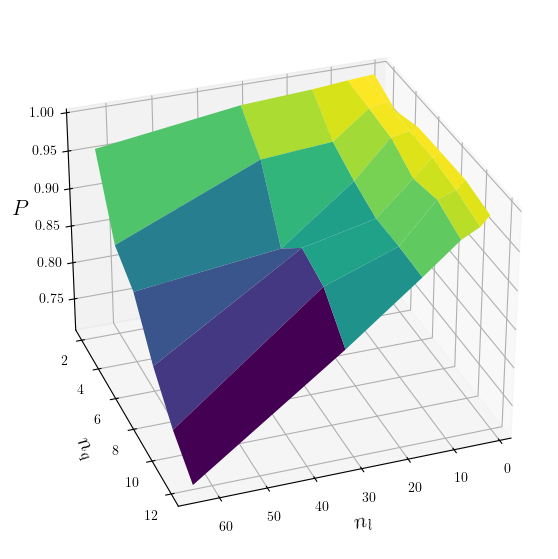

In [62]:
# Contour plot
x = [2,       4,       8,       16,        32,        64]
y = [2, 4, 6, 8, 10, 12]
x_grid, y_grid = np.meshgrid(x, y)
z = data_set_1
#Surface plot
x_grid = np.array(x_grid)
y_grid = np.array(y_grid)
z = np.array(z)
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(x_grid, y_grid, z, cmap='viridis', edgecolor='none')
# Add labels and color bar
ax.set_xlabel('$n_l$', fontsize=16, fontname='Times New Roman')
ax.set_ylabel('$n_q$', fontsize=16, fontname='Times New Roman')
#plt.zlabel('$n_q$', fontsize=16, fontname='Times New Roman')
ax.set_zlabel('$P$', fontsize=16, fontname='Times New Roman')
#fig.colorbar(surf, ax=ax, label='$P$')
ax.view_init(elev=30, azim=70)

plt.show()



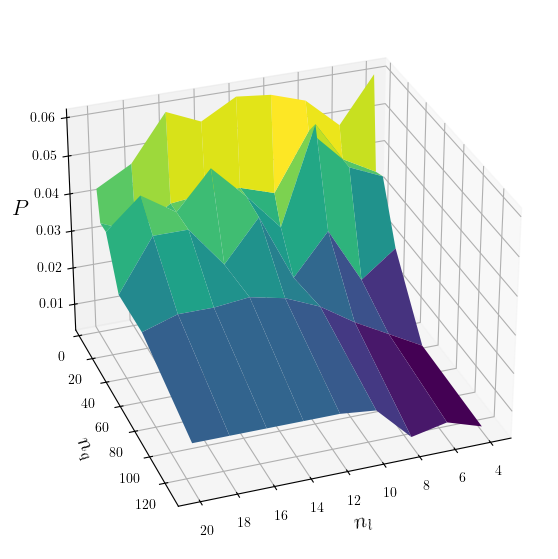

In [63]:
#Surface plot
x_grid, y_grid = np.meshgrid(n_q, n_l)
z = delta_th
z = np.array(z)
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(x_grid, y_grid, z, cmap='viridis', edgecolor='none')

# Add labels and color bar
ax.set_xlabel('$n_l$', fontsize=16, fontname='Times New Roman')
ax.set_ylabel('$n_q$', fontsize=16, fontname='Times New Roman')
ax.set_zlabel('$P$', fontsize=16, fontname='Times New Roman')
ax.view_init(elev=30, azim=70)

plt.show()

### Plot both graphs in a single plot

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
Failed to find a Ghostscript installation.  Distillation step skipped.


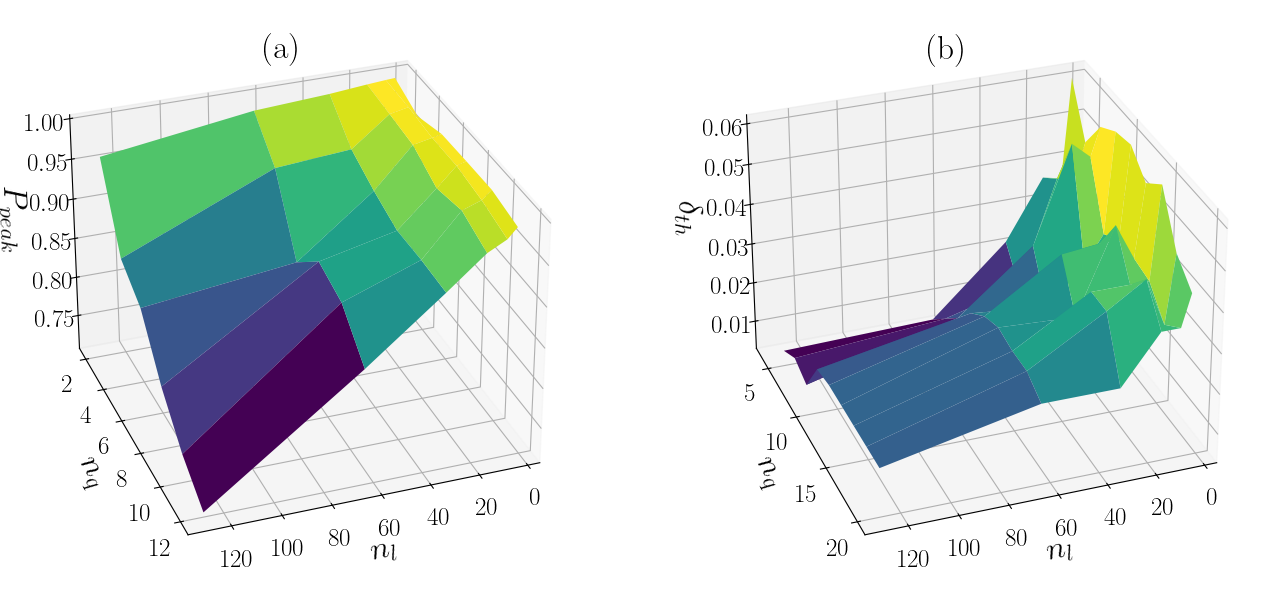

In [64]:
from mpl_toolkits.mplot3d import Axes3D
# --------- First Dataset ---------
x1 = [4, 8, 16, 32, 64, 128]
y1 = [2, 4, 6, 8, 10, 12]
x1_grid, y1_grid = np.meshgrid(x1, y1)
z1 = np.array(data_set_1)  # Make sure data_set_1 is defined and matches shape of grid

# --------- Second Dataset ---------
x2 = n_l  # Make sure n_q and n_l are defined and compatible
y2 = n_q
x2_grid, y2_grid = np.meshgrid(x2, y2)
z2 = np.array(delta_th)  # Ensure it matches shape of meshgrid
z2 = z2.T
# --------- Create Figure with Subplots ---------
fig = plt.figure(figsize=(14, 6))

plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'Times New Roman' 

# First subplot
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(x1_grid, y1_grid, z1, cmap='viridis', edgecolor='none')
#ax1.set_title('(a)', fontsize=20)
ax1.text(60, 2, 1.05, '(a)', fontsize=24, color='black')  # (x, y, text)
ax1.set_xlabel('$n_l$', fontsize=24, fontname='Times New Roman')
ax1.set_ylabel('$n_q$', fontsize=24, fontname='Times New Roman')
ax1.set_zlabel('$P_{peak}$', fontsize=24, fontname='Times New Roman', labelpad=10,)
ax1.view_init(elev=30, azim=70)
ax1.tick_params(axis='x', labelsize=18) 
ax1.tick_params(axis='y', labelsize=18)
ax1.tick_params(axis='z', labelsize=18)

# Second subplot
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.text(60, 2, 0.067, '(b)', fontsize=24, color='black')  # (x, y, text)
surf2 = ax2.plot_surface(x2_grid, y2_grid, z2, cmap='viridis', edgecolor='none')
ax2.set_xlabel('$n_l$', fontsize=24, fontname='Times New Roman')
ax2.set_ylabel('$n_q$', fontsize=24, fontname='Times New Roman')
ax2.tick_params(axis='x', labelsize=18) 
ax2.tick_params(axis='y', labelsize=18)
ax2.tick_params(axis='z', labelsize=18)
ax2.set_zlabel('$\delta_{th}$', fontsize=24, fontname='Times New Roman', labelpad=10, rotation=0.5)
ax2.zaxis.label.set_rotation(0) 
ax2.view_init(elev=30, azim=70)

plt.tight_layout()
plt.savefig("figure_delta.eps", format='eps', dpi=300, bbox_inches='tight')
plt.show()